In [1]:
import numpy as np
import xarray as xr
from cftime import num2date, date2num
import toml
import munch

In [2]:
def aggregate_var(dataset: xr.Dataset, method:str, dim:str='time'):
    eval_str = f"dataset.{method}(dim='{dim}',skipna=True,keep_attrs=True)"
    output = eval(eval_str)
    return output
    

In [3]:
config = munch.munchify(toml.load("/home/jovyan/work/codes/ML4Fires/config/cmip6_inference.toml"))
searfire_ds_path = "/home/jovyan/data/ML4Fires_data/data_100km.zarr"
seafire_ds = xr.open_zarr(searfire_ds_path)

In [4]:
seafire_ds["lsm"].min().values,seafire_ds["lsm"].max().values,seafire_ds["lsm"].mean().values 

(array(0., dtype=float32),
 array(1., dtype=float32),
 array(0.36430556, dtype=float32))

In [5]:
dates = ['2030-01-08','2030-01-16','2030-01-24',
         '2030-02-08','2030-02-16','2030-02-24',
         '2030-03-08','2030-03-16','2030-03-24',
         '2030-04-08','2030-04-16','2030-04-24',
         '2030-05-08','2030-05-16','2030-05-24',
         '2030-06-08','2030-06-16','2030-06-24',
         '2030-07-08','2030-07-16','2030-07-24',
         '2030-08-08','2030-08-16','2030-08-24',
         '2030-09-08','2030-09-16','2030-09-24',
         '2030-10-08','2030-10-16','2030-10-24',
         '2030-11-08','2030-11-16','2030-11-24',
         '2030-12-08','2030-12-16','2030-12-24'] #yyyy-mm-dd
np_dates = [np.datetime64(f"{date}T12:00:00.00") for date in dates]
n_prior_days = 8

dates_range_np = [[np_date - np.timedelta64(n_prior_days-1, "D"), np_date] for np_date in np_dates]

In [6]:
dates_range_cfttime = []
for single_date_range in dates_range_np:
    py_date = [single_np_date.astype('datetime64[ms]').astype(object) for single_np_date in single_date_range]
    units = "days since 0000-01-01"
    calendar = "noleap"
    numeric_time = date2num(py_date, units, calendar, has_year_zero=True)
    dates_range_cfttime.append(num2date(numeric_time, units, calendar, has_year_zero=True))


In [7]:
import os

cmip6_var_filename = {}
for var_key, var_value in config.data.drivers.items():
    cmip6_var_filename[var_key] = []
    if var_value.type == "dynamic":
        path_to_files = var_value.cmip6_path.replace("[scenario]", config.config.cmip6_scenario)
        list_of_files = [file for file in os.listdir(path_to_files) if file.endswith(".nc")]
        for file in list_of_files:
            date = file.split("_")[-1].split(".")[0].split("-")
            start_date = np.datetime64(f"{date[0][0:4]}-{date[0][4:6]}-{date[0][6:8]}")
            end_date = np.datetime64(f"{date[1][0:4]}-{date[1][4:6]}-{date[1][6:8]}")
            for date_range in dates_range_np:
                if min(date_range) >= start_date and max(date_range)<=end_date and f"{path_to_files}{file}" not in cmip6_var_filename[var_key]:
                    cmip6_var_filename[var_key].append(f"{path_to_files}{file}")
    else:
        path_to_file = var_value.cmip6_path.replace("[scenario]", config.config.cmip6_scenario)
        file = [file for file in os.listdir(path_to_file) if file.endswith(".nc")]
        cmip6_var_filename[var_key] = f"{path_to_file}/{file[0]}"
        
        

In [8]:
cmip6_var_filename

{'lai': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/Eday/lai/gn/v20210126/lai_Eday_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20641231.nc'],
 'tas': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/day/tas/gn/v20210126/tas_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc'],
 'hur': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/day/hur/gn/v20210126/hur_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20290101-20301231.nc'],
 'tasmin': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/day/tasmin/gn/v20210126/tasmin_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc'],
 'pr': ['/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/day/pr/gn/v20210126/pr_day_CMCC-ESM2_ssp126_r1i1p1f1_gn_20150101-20391231.nc'],
 'sftlf': '/home/jovyan/data/CMIP6/ScenarioMIP/CMCC/CMCC-ESM2/ssp126/r1i1p1f1/fx/sftlf/gn/v20210126//sftlf_fx_CMCC-ESM2_ssp126_r1i1p1f1_gn.nc'}

In [9]:
var_ds_list = []
for var_name, var_file in cmip6_var_filename.items():
    if config.data.drivers[var_name].aggregation.lower() != "none":
        ds_var = xr.open_mfdataset(var_file)[var_name]
        ds_var_time_slices = []
        for single_range_cfttime in dates_range_cfttime:
            ds_var_time_slices.append(ds_var.sel(time=slice(single_range_cfttime[0],single_range_cfttime[1])))
    else:
        ds_var = xr.open_dataset(var_file)[var_name]/100 # divide by 100 to get the same units as training dataset
    if config.data.drivers[var_name].aggregation.lower() != "none":
        for slice_idx, single_time_slice in enumerate(ds_var_time_slices):
            if var_name == "pr":
                single_time_slice = single_time_slice*3600*24 # Convering flux to total precipitation
            ds_var_time_slices[slice_idx] = aggregate_var(dataset=single_time_slice,method=config.data.drivers[var_name].aggregation,dim='time')
            ds_var_time_slices[slice_idx] = ds_var_time_slices[slice_idx].expand_dims({"time":[dates_range_np[slice_idx][-1]]})
    
        ds_var = xr.concat(ds_var_time_slices, dim="time")
    ds_var = ds_var.assign_coords({"lon": ((ds_var.lon + 180) % 360) - 180}).sortby("lon") # translating the longitude values
    ds_var = ds_var.rename({"lon":"longitude", "lat":"latitude"}) # renaming longitude and latitude for regridding
    ds_var = ds_var.interp_like(seafire_ds[["longitude","latitude"]])
    var_ds_list.append(ds_var)
                                      
ds = xr.merge(var_ds_list)
ds = ds.isel(plev=0) # This is selected for the variable which also dependso on the pressure - this selects the sea level pressure
ds_array = ds.to_array().transpose("time", "variable", "latitude", "longitude").values

In [10]:
from tqdm import tqdm
import torch

import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.utils_mlflow import load_model_from_mlflow
from Fires._utilities.utils_inference import get_scaler, process_and_plot_cmip6infer

In [11]:
# run_name=input()
run_name="last"
registered_model = load_model_from_mlflow(run_name, provenance=True)
# registered_model

Data from MLFlow downloaded in: /home/jovyan/work/codes/ML4Fires/MLFLOW/last


2025/04/18 13:10:53 WARNING mlflow.pytorch: Stored model version '2.4.1+cu121' does not match installed PyTorch version '2.4.1+cu124'


In [12]:
scaler = get_scaler(run_name=run_name)
transformed_ds = scaler.transform(torch.as_tensor(ds_array))
transformed_ds = transformed_ds.float()
transformed_ds = torch.nan_to_num(transformed_ds,nan=0)

prediction_cpu = []
with torch.no_grad():
    for idx in range(transformed_ds.shape[0]):
        prediction = registered_model(transformed_ds[idx].unsqueeze(0).to('cuda:0'))
        prediction_cpu.append(prediction.cpu().detach().numpy())
predictions = np.vstack(prediction_cpu).squeeze()


In [13]:
ds_predictions = xr.Dataset(data_vars={"global_burned_areas":(("time","latitude","longitude"),predictions)},
                            coords={"time":("time", np_dates), "longitude":("longitude", seafire_ds.longitude.values),
                                    "latitude":("latitude", seafire_ds.latitude.values)},
                           attrs={"Details": f"CMIP6 prediction for the scenario {config.config.cmip6_scenario} between the dates {min(np_dates)} and {max(np_dates)}. Prediction is made for the InterTwin Project.",
                                  "Processing": "No information",
                                 "Source": "CMCC Foundation."})
                                                              

In [14]:
ds_predictions

<xarray.Dataset> Size: 9MB
Dimensions:              (time: 36, latitude: 180, longitude: 360)
Coordinates:
  * time                 (time) datetime64[ms] 288B 2030-01-08T12:00:00 ... 2...
  * longitude            (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude             (latitude) float64 1kB 89.5 88.5 87.5 ... -88.5 -89.5
Data variables:
    global_burned_areas  (time, latitude, longitude) float32 9MB 4.254e-07 .....
Attributes:
    Details:     CMIP6 prediction for the scenario ssp126 between the dates 2...
    Processing:  No information
    Source:      CMCC Foundation.

['lai', 'lst_day', 'rel_hum', 'sst', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)
Is DataArray - AVG: (180, 360) STD: (180, 360)
 Mean of data: (180, 360)
 Max: 2911.06005859375 	 Min: 0.0
 Lats Max: 251.41000366210938 	 Lons Max: 135.72999572753906
 Mean of data: (180, 360)
 Max: 5179.89013671875 	 Min: 0.0
 Lats Max: 395.30999755859375 	 Lons Max: 209.69000244140625


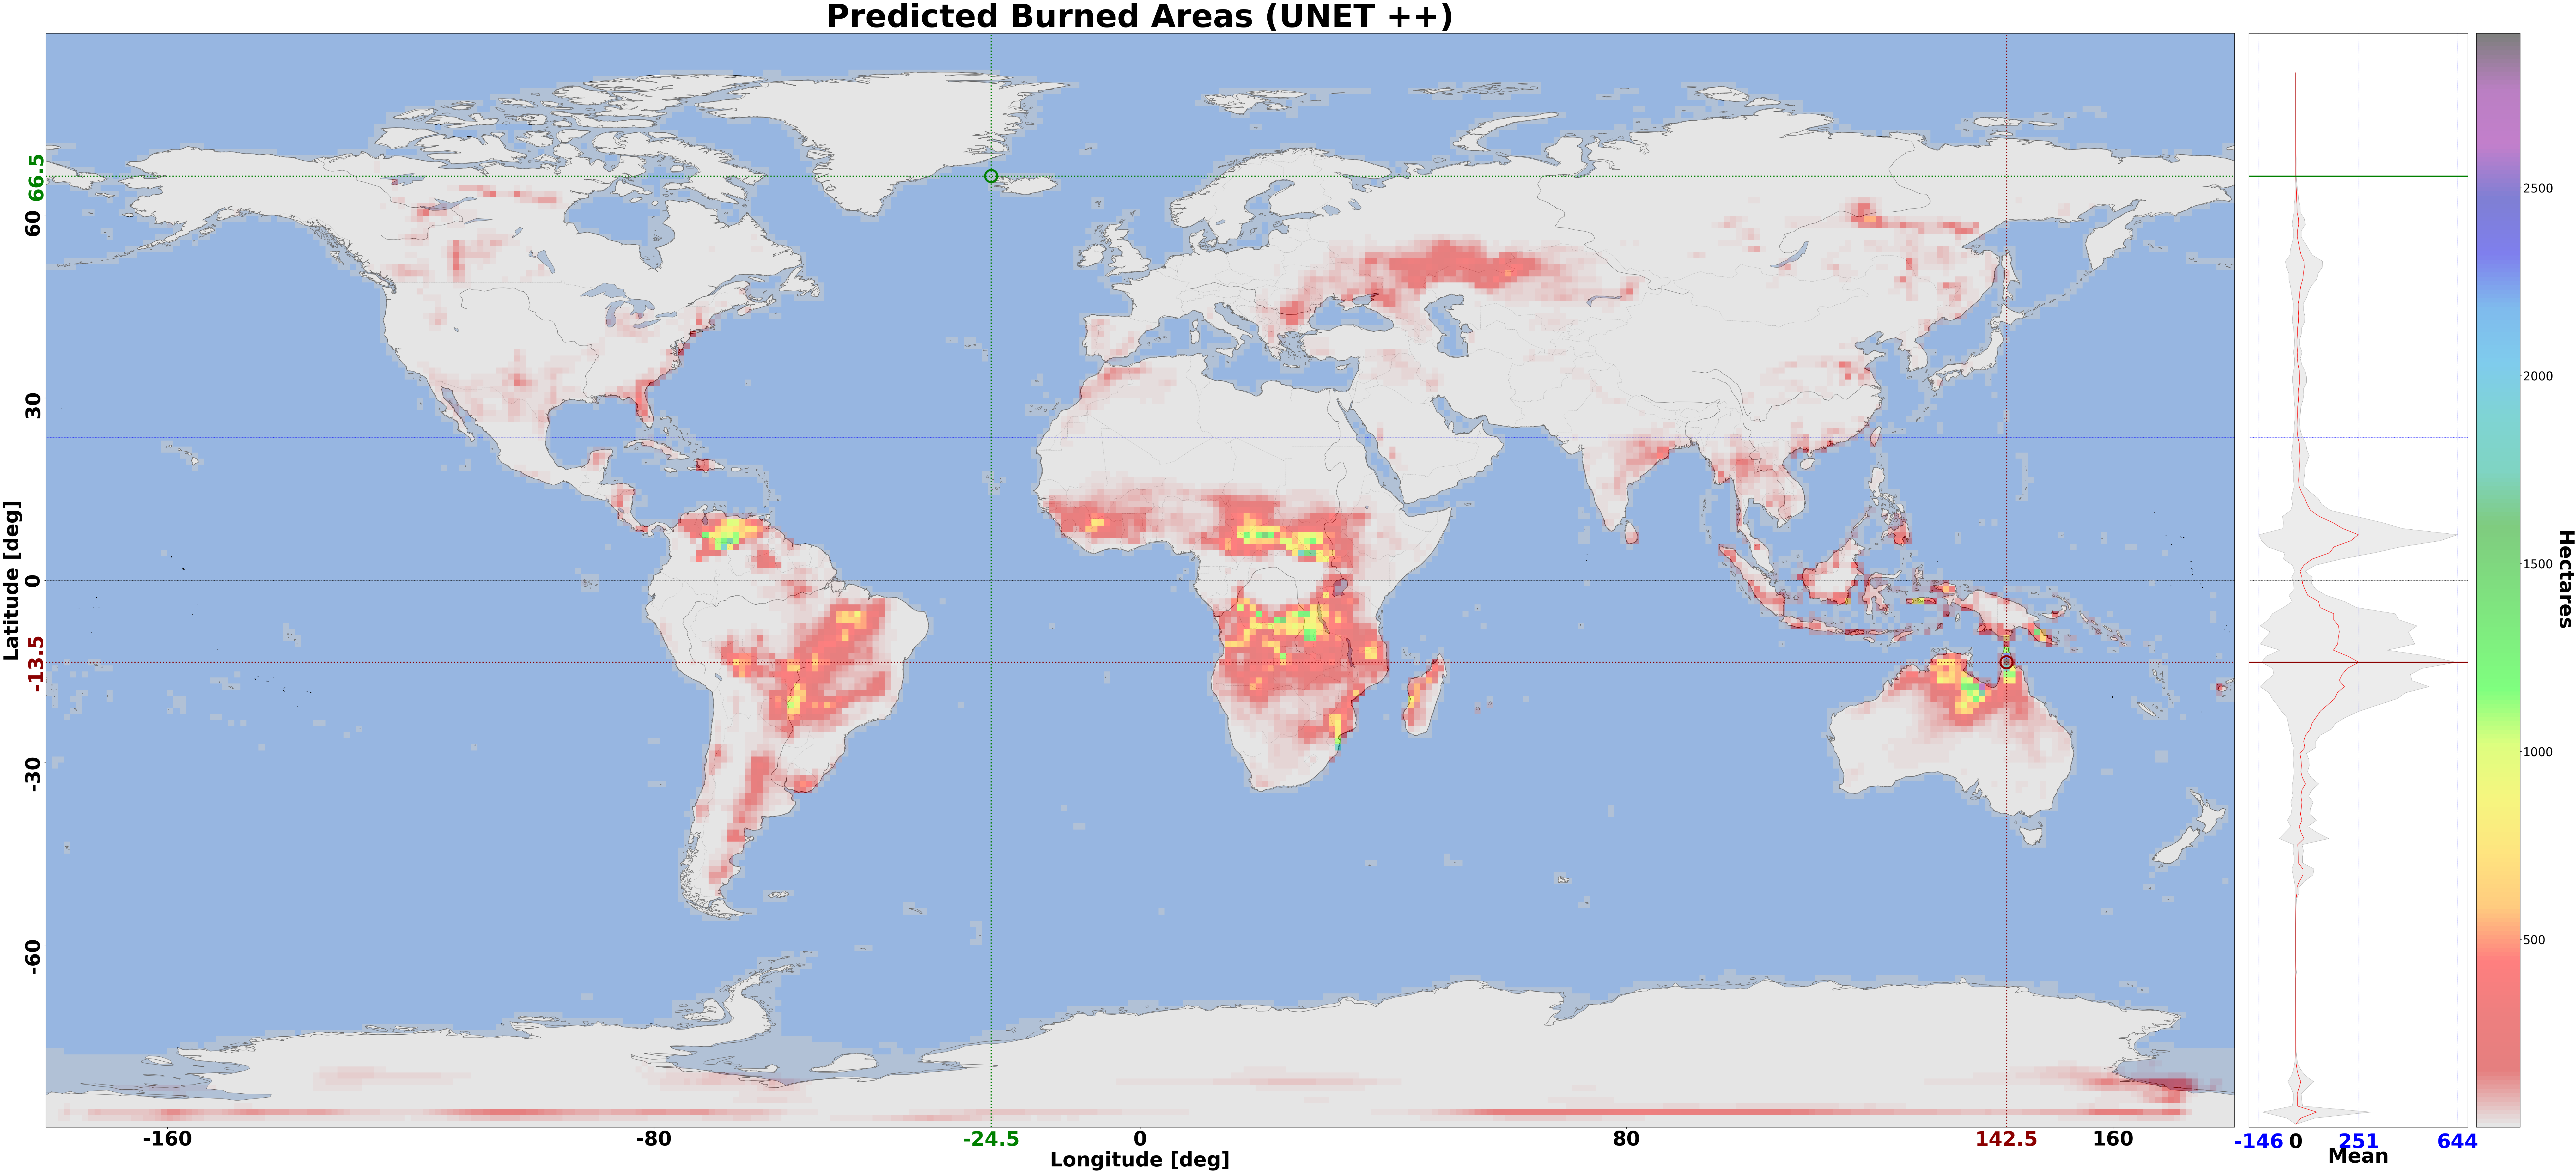

In [16]:
from Fires._utilities.utils_inference import process_and_plot_data, load_input_data

input_data = load_input_data(searfire_ds_path, '2019', '2020')

process_and_plot_cmip6infer(
	data=ds_predictions["global_burned_areas"],
	temporal_aggregate_scheme=["average","average","average"],
	label='Predicted Burned Areas',
	lats=seafire_ds.latitude.values,
	lons=seafire_ds.longitude.values,
	model_name="Unet ++"
)